In [1]:
import pandas as pd
import numpy as np

#Load CSV
df=pd.read_csv('btissue.csv')
print("\n---Dataset Preview---")
print(df.head())

#Basic Info
print("\n---Dataset Info--")
print(df.info())

#Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

#Summary statistics
print("\n---Summary Statistics---")
print(df.describe())


---Dataset Preview---
           I0     PA500       HFS          DA          Area       A/DA  \
0  524.794072  0.187448  0.032114  228.800228   6843.598481  29.910803   
1  330.000000  0.226893  0.265290  121.154201   3163.239472  26.109202   
2  551.879287  0.232478  0.063530  264.804935  11888.391830  44.894903   
3  380.000000  0.240855  0.286234  137.640111   5402.171180  39.248524   
4  362.831266  0.200713  0.244346  124.912559   3290.462446  26.342127   

      Max IP          DR           P class  
0  60.204880  220.737212  556.828334   car  
1  69.717361   99.084964  400.225776   car  
2  77.793297  253.785300  656.769449   car  
3  88.758446  105.198568  493.701814   car  
4  69.389389  103.866552  424.796503   car  

---Dataset Info--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I0      106 non-null    float64
 1   PA500   106 non-null  


---KNN Results---
Accuracy: 0.3333333333333333
Precision:  0.16666666666666666
Recall: 0.5
F1-Score: 0.25


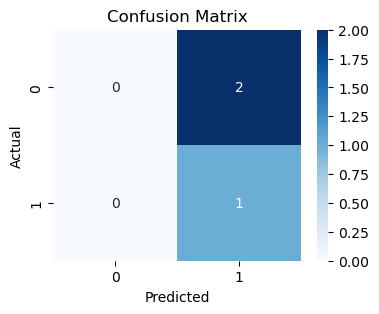

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

X=np.array([[1,2],[2,3],[3,3],[6,5],[7,7],[8,6]])
Y=np.array([0,0,0,1,1,1])

X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=3,random_state=42)

knn=KNeighborsClassifier(n_neighbors=3)
model=knn.fit(X_train,y_train)
y_pred=model.predict(X_test)

print("\n---KNN Results---")
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision: ",precision_score(y_test,y_pred,average='macro',zero_division=0))
print("Recall:", recall_score(y_test,y_pred,average='macro',zero_division=0))
print("F1-Score:",f1_score(y_test,y_pred,average='macro',zero_division=0))

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

           I0     PA500       HFS          DA          Area       A/DA  \
0  524.794072  0.187448  0.032114  228.800228   6843.598481  29.910803   
1  330.000000  0.226893  0.265290  121.154201   3163.239472  26.109202   
2  551.879287  0.232478  0.063530  264.804935  11888.391830  44.894903   
3  380.000000  0.240855  0.286234  137.640111   5402.171180  39.248524   
4  362.831266  0.200713  0.244346  124.912559   3290.462446  26.342127   

      Max IP          DR           P class  
0  60.204880  220.737212  556.828334   car  
1  69.717361   99.084964  400.225776   car  
2  77.793297  253.785300  656.769449   car  
3  88.758446  105.198568  493.701814   car  
4  69.389389  103.866552  424.796503   car  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I0      106 non-null    float64
 1   PA500   106 non-null    float64
 2   HFS     106 non-null    flo

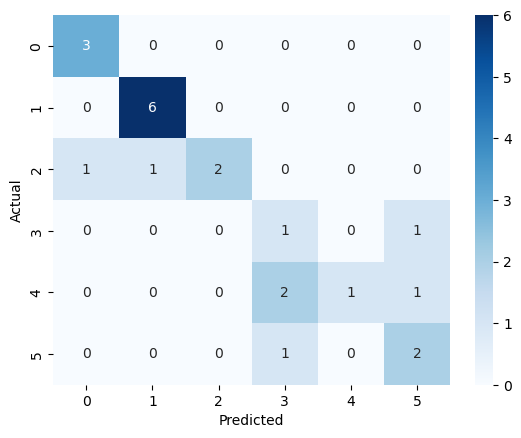

In [14]:
import numpy as np
import pandas as pd
df=pd.read_csv('btissue.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
# Features and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
# Predictions
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()